# Regresja logistyczna na zbiorze Iris

Żeby zachować binarny charakter klasyfikacji, użyłem dwie klasy: setosa i reszta.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve
)

In [17]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# 0 = setosa
# 1 = versicolor + virginica
y = (y != 0).astype(int)

# szybka kontrola
print(y.value_counts())

target
1    100
0     50
Name: count, dtype: int64


Zbiór danych jest umiarkowanie niezbalansowany:
- klasa 1 (versicolor + virginica): 100 próbek
- klasa 0 (setosa): 50 próbek

Zatem klasa pozytywna (1) występuje dwukrotnie częściej. Taka nierównowaga wskazuje na to że trzeba potem użyć `class_weight="balanced"` w modelu regresji logistycznej.

In [18]:
Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [19]:
base = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

base.fit(Xtr, ytr)

p_base = base.predict_proba(Xte)[:, 1]

In [20]:
def odds(p): return p / (1 - p)
def logit(p): return np.log(p / (1 - p))

ex = pd.DataFrame({
    "p": p_base[:5],
    "odds": odds(p_base[:5]),
    "logit": logit(p_base[:5])
})

print(ex.round(4))

        p       odds   logit
0  0.0098     0.0098 -4.6205
1  0.9987   745.5831  6.6142
2  0.0159     0.0161 -4.1278
3  0.9992  1190.4798  7.0821
4  0.0181     0.0184 -3.9929


Wyniki pokazują bardzo wyraźne rozdzielenie klas.

- bardzo małe prawdopodobieństwa (np. p ≈ 0.01) odpowiadają bardzo małym odds i silnie ujemnym logitom,
- bardzo duże prawdopodobieństwa (p ≈ 0.99) prowadzą do bardzo dużych odds i dodatnich logitów.

Odds rosną nieliniowo wraz z p.
Widać bardzo „pewną” klasyfikację, model często daje wartości bliskie 0 lub 1.

In [21]:
auc = roc_auc_score(yte, p_base)
apr = average_precision_score(yte, p_base)
brier = brier_score_loss(yte, p_base)

print(f"AUC-ROC={auc:.3f}")
print(f"AUC-PR={apr:.3f}")
print(f"Brier={brier:.3f}")

AUC-ROC=1.000
AUC-PR=1.000
Brier=0.002


- AUC-ROC = 1 oznacza perfekcyjne rozdzielenie klas,
- AUC-PR = 1 oznacza idealną jakość predykcji dla klasy pozytywnej,
- bardzo niski Brier score wskazuje, że przewidywane prawdopodobieństwa są niemal idealnie zgodne z rzeczywistością.

Platt Brier: 0.013183851685175113
Isotonic Brier: 0.0005693246312653845


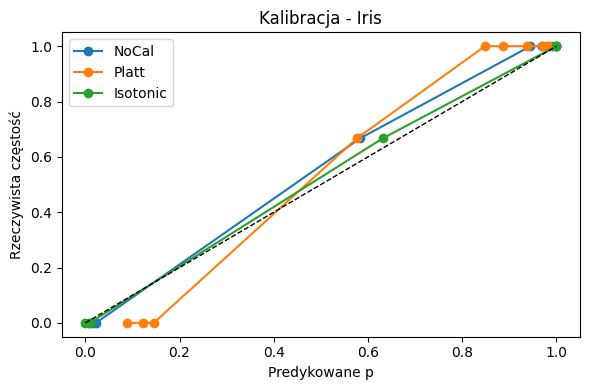

In [22]:
platt = CalibratedClassifierCV(base, method="sigmoid", cv=5).fit(Xtr, ytr)
iso = CalibratedClassifierCV(base, method="isotonic", cv=5).fit(Xtr, ytr)

p_platt = platt.predict_proba(Xte)[:, 1]
p_iso = iso.predict_proba(Xte)[:, 1]

print("Platt Brier:", brier_score_loss(yte, p_platt))
print("Isotonic Brier:", brier_score_loss(yte, p_iso))

fig, ax = plt.subplots(figsize=(6,4))

for name, p in [
    ("NoCal", p_base),
    ("Platt", p_platt),
    ("Isotonic", p_iso)
]:
    frac_pos, mean_pred = calibration_curve(
        yte, p, n_bins=10, strategy='quantile'
    )
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel("Predykowane p")
ax.set_ylabel("Rzeczywista częstość")
ax.set_title("Kalibracja - Iris")
ax.legend()
plt.tight_layout()
plt.show()

Model bazowy był już dobrze skalibrowany.
Kalibracja izotoniczna poprawiła jakość (uzyskano niższy Brier score),
Metoda Platta pogorszyła jakość (uzyskano wyższy Brier score),

Na wykresie wszystkie krzywe są blisko przekątnej idealnej kalibracji, jednak izotoniczna pozostaje najbliżej niej w całym zakresie, a Platta odchyla się najbardziej.

In [23]:
fpr, tpr, thr = roc_curve(yte, p_iso)

best_idx = np.argmax(tpr - fpr)
thr_best = thr[best_idx]

print("Próg Youdena:", thr_best)

yhat = (p_iso >= thr_best).astype(int)

print(confusion_matrix(yte, yhat))

Próg Youdena: 0.8835579665688755
[[13  0]
 [ 0 25]]


Macierz pomyłek:
- True negatives = 13
- False positives = 0
- False negatives = 0
- True positives = 25

Model osiąga idealne rozdzielenie klas i nie popełnia żadnych błędów klasyfikacji (brak FP (błędów typu I)i FN (błędów typu II)). Oznacza to, że przy wybranym progu klasyfikacja jest perfekcyjna dla tego zbioru danych.

In [24]:
lr = base.named_steps["lr"]

coefs = lr.coef_.ravel()

or_df = pd.DataFrame({
    "cecha": X.columns,
    "beta": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("odds_ratio", ascending=False)

print(or_df)

               cecha      beta  odds_ratio
2  petal length (cm)  1.635003    5.129473
3   petal width (cm)  1.559169    4.754869
0  sepal length (cm)  1.077810    2.938239
1   sepal width (cm) -1.101922    0.332232


Największy wpływ na klasyfikację mają cechy `petal length`, `petal width` i `sepal length`.

Wzrost tych cech silnie zwiększa szansę przypisania do klasy pozytywnej - gatunku `versicolor` lub `virginica` (innej niż `setosa`).

Jest jednak cecha o wpływie negatywnym - sepal width (odds ratio mniejsze od 1), jej wzrost zmniejsza prawdopodobieństwo klasy pozytywnej.

Najsilniejszym predyktorem są zatem cechy płatków.

### Wnioski

**1. Skalibrowanie modelu**  
Model regresji logistycznej dla danych Iris był bardzo dobrze skalibrowany już w wersji bazowej (Brier ≈ 0.002). Kalibracja izotoniczna dodatkowo poprawiła dopasowanie prawdopodobieństw, natomiast metoda Platta pogorszyła wynik. Oznacza to, że w tym przypadku model liniowy naturalnie dobrze odwzorowuje prawdopodobieństwa.

**2. Najważniejsze cechy**  
Największy wpływ na klasyfikację miały cechy związane z płatkami (petal length i petal width), które znacząco zwiększały szansę przynależności do klasy pozytywnej. Sepal width działał w przeciwnym kierunku, zmniejszając to prawdopodobieństwo. Potwierdza to, że cechy płatków są kluczowe w rozróżnianiu gatunków w zbiorze Iris.

**3. Dobór progu decyzyjnego**  
Wyznaczony próg Youdena (≈ 0.884) pozwolił uzyskać idealną klasyfikację (brak błędów FP i FN). Oznacza to, że model w tym przypadku osiąga pełną separację klas i próg nie wymaga kompromisu między czułością a specyficznością.

**4. Podsumowanie**  
Model dla zbioru Iris osiągnął niemal perfekcyjne wyniki, co wynika z bardzo dobrej separowalności klas w danych.